In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/datathon-2026-round-1/products.csv
/kaggle/input/competitions/datathon-2026-round-1/sample_submission.csv
/kaggle/input/competitions/datathon-2026-round-1/promotions.csv
/kaggle/input/competitions/datathon-2026-round-1/shipments.csv
/kaggle/input/competitions/datathon-2026-round-1/order_items.csv
/kaggle/input/competitions/datathon-2026-round-1/reviews.csv
/kaggle/input/competitions/datathon-2026-round-1/inventory.csv
/kaggle/input/competitions/datathon-2026-round-1/returns.csv
/kaggle/input/competitions/datathon-2026-round-1/sales.csv
/kaggle/input/competitions/datathon-2026-round-1/orders.csv
/kaggle/input/competitions/datathon-2026-round-1/geography.csv
/kaggle/input/competitions/datathon-2026-round-1/customers.csv
/kaggle/input/competitions/datathon-2026-round-1/baseline.ipynb
/kaggle/input/competitions/datathon-2026-round-1/payments.csv
/kaggle/input/competitions/datathon-2026-round-1/web_traffic.csv


In [2]:
import pandas as pd
import numpy as np
import os
import gc

# 1. Định nghĩa đường dẫn
BASE_PATH = '/kaggle/input/competitions/datathon-2026-round-1/'

def load_and_prep_data():
    print("🚀 Đang khởi tạo và load dữ liệu từ:", BASE_PATH)
    
    # Load các bảng cơ bản
    orders = pd.read_csv(BASE_PATH + 'orders.csv', parse_dates=['order_date'])
    products = pd.read_csv(BASE_PATH + 'products.csv')
    payments = pd.read_csv(BASE_PATH + 'payments.csv')
    customers = pd.read_csv(BASE_PATH + 'customers.csv')
    order_items = pd.read_csv(BASE_PATH + 'order_items.csv')
    shipments = pd.read_csv(BASE_PATH + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
    web_traffic = pd.read_csv(BASE_PATH + 'web_traffic.csv', parse_dates=['date'])
    returns = pd.read_csv(BASE_PATH + 'returns.csv')
    reviews = pd.read_csv(BASE_PATH + 'reviews.csv')
    geo = pd.read_csv(BASE_PATH + 'geography.csv')
    inventory = pd.read_csv(BASE_PATH + 'inventory.csv', parse_dates=['snapshot_date'])
    sales = pd.read_csv(BASE_PATH + 'sales.csv')

    # Xử lý nhanh Null và Feature Engineering cơ bản
    customers['age_group'] = customers['age_group'].fillna('Unknown')
    orders['month'] = orders['order_date'].dt.to_period('M').astype(str)
    orders['year'] = orders['order_date'].dt.year

    # 4. Thực hiện các bước JOIN chính theo Cardinality
    # Join 1:1:1 (Orders - Payments - Customers)
    df_master = orders.merge(payments, on='order_id', how='left')
    df_master = df_master.merge(customers, on='customer_id', how='left')

    # Join Logistics (Shipments - Reviews - Geo)
    df_logistics = shipments.merge(reviews, on='order_id', how='left')
    df_logistics = df_logistics.merge(orders[['order_id', 'zip']], on='order_id', how='left')
    df_logistics = df_logistics.merge(geo, on='zip', how='left')

    # Join Inventory & Products
    df_inventory_master = inventory.merge(products, on='product_id', how='left')

    
    return {
        'orders': orders,
        'products': products,
        'payments': payments,
        'customers': customers,
        'order_items': order_items,
        'shipments': shipments,
        'web_traffic': web_traffic,
        'returns': returns,
        'reviews': reviews,
        'geo': geo,
        'inventory': inventory,
        'sales': sales,
        'df_master': df_master,
        'df_logistics': df_logistics,
        'df_inventory_master': df_inventory_master
    }

# Gọi hàm để lấy dữ liệu
data = load_and_prep_data()

🚀 Đang khởi tạo và load dữ liệu từ: /kaggle/input/competitions/datathon-2026-round-1/


/tmp/ipykernel_16/1915307002.py:17: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_PATH + 'order_items.csv')


In [3]:
# Giải nén các dataframe để dùng trực tiếp
orders = data['orders']
products = data['products']
payments = data['payments']
customers = data['customers']
order_items = data['order_items']
df_master = data['df_master']
df_logistics = data['df_logistics']
web_traffic = data['web_traffic']
returns = data['returns']
sales = data['sales']
geo = data['geo']

print("✅ Đã sẵn sàng phân tích!")
display(df_master.head())

✅ Đã sẵn sàng phân tích!


,order_id,order_date,customer_id,zip_x,order_status,payment_method_x,device_type,order_source,month,year,payment_method_y,payment_value,installments,zip_y,city,signup_date,gender,age_group,acquisition_channel
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2012-07,2012,credit_card,7967.54,3,1109,Hanoi,2020-06-06,Female,35-44,social_media
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,2012-07,2012,cod,71163.75,1,1330,Phu Ly,2021-11-03,Female,18-24,social_media
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,2012-07,2012,credit_card,33660.99,3,1473,Lao Cai,2020-09-18,Female,35-44,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,2012-07,2012,credit_card,53196.25,3,2360,Son Tay,2016-05-29,Male,45-54,direct
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,2012-07,2012,paypal,1597.84,1,2886,Uong Bi,2017-07-11,Male,18-24,social_media


In [4]:
# Display summary statistics for the orders dataframe
display(orders.describe(include='all'))

# Display basic info including non-null counts and data types
print('\nDataFrame Info:')
display(orders.info())

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,month,year
count,646945.000000,646945,646945.000000,646945.000000,646945,646945,646945,646945,646945,646945.000000
unique,NaN,NaN,NaN,NaN,6,5,3,6,126,NaN
top,NaN,NaN,NaN,NaN,delivered,credit_card,mobile,organic_search,2018-06,NaN
freq,NaN,NaN,NaN,NaN,516716,356352,291482,181495,10851,NaN
mean,417189.470332,2016-11-28 05:46:39.463323904,84906.203535,55410.740423,NaN,NaN,NaN,NaN,NaN,2016.410148
min,1.000000,2012-07-04 00:00:00,1.000000,1001.000000,NaN,NaN,NaN,NaN,NaN,2012.000000
25%,208728.000000,2014-08-05 00:00:00,41336.000000,30904.000000,NaN,NaN,NaN,NaN,NaN,2014.000000
50%,417211.000000,2016-07-25 00:00:00,87279.000000,54129.000000,NaN,NaN,NaN,NaN,NaN,2016.000000
75%,625628.000000,2018-08-27 00:00:00,133282.000000,83301.000000,NaN,NaN,NaN,NaN,NaN,2018.000000
max,834397.000000,2022-12-31 00:00:00,157563.000000,99950.000000,NaN,NaN,NaN,NaN,NaN,2022.000000



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  object        
 5   payment_method  646945 non-null  object        
 6   device_type     646945 non-null  object        
 7   order_source    646945 non-null  object        
 8   month           646945 non-null  object        
 9   year            646945 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(5)
memory usage: 46.9+ MB


None

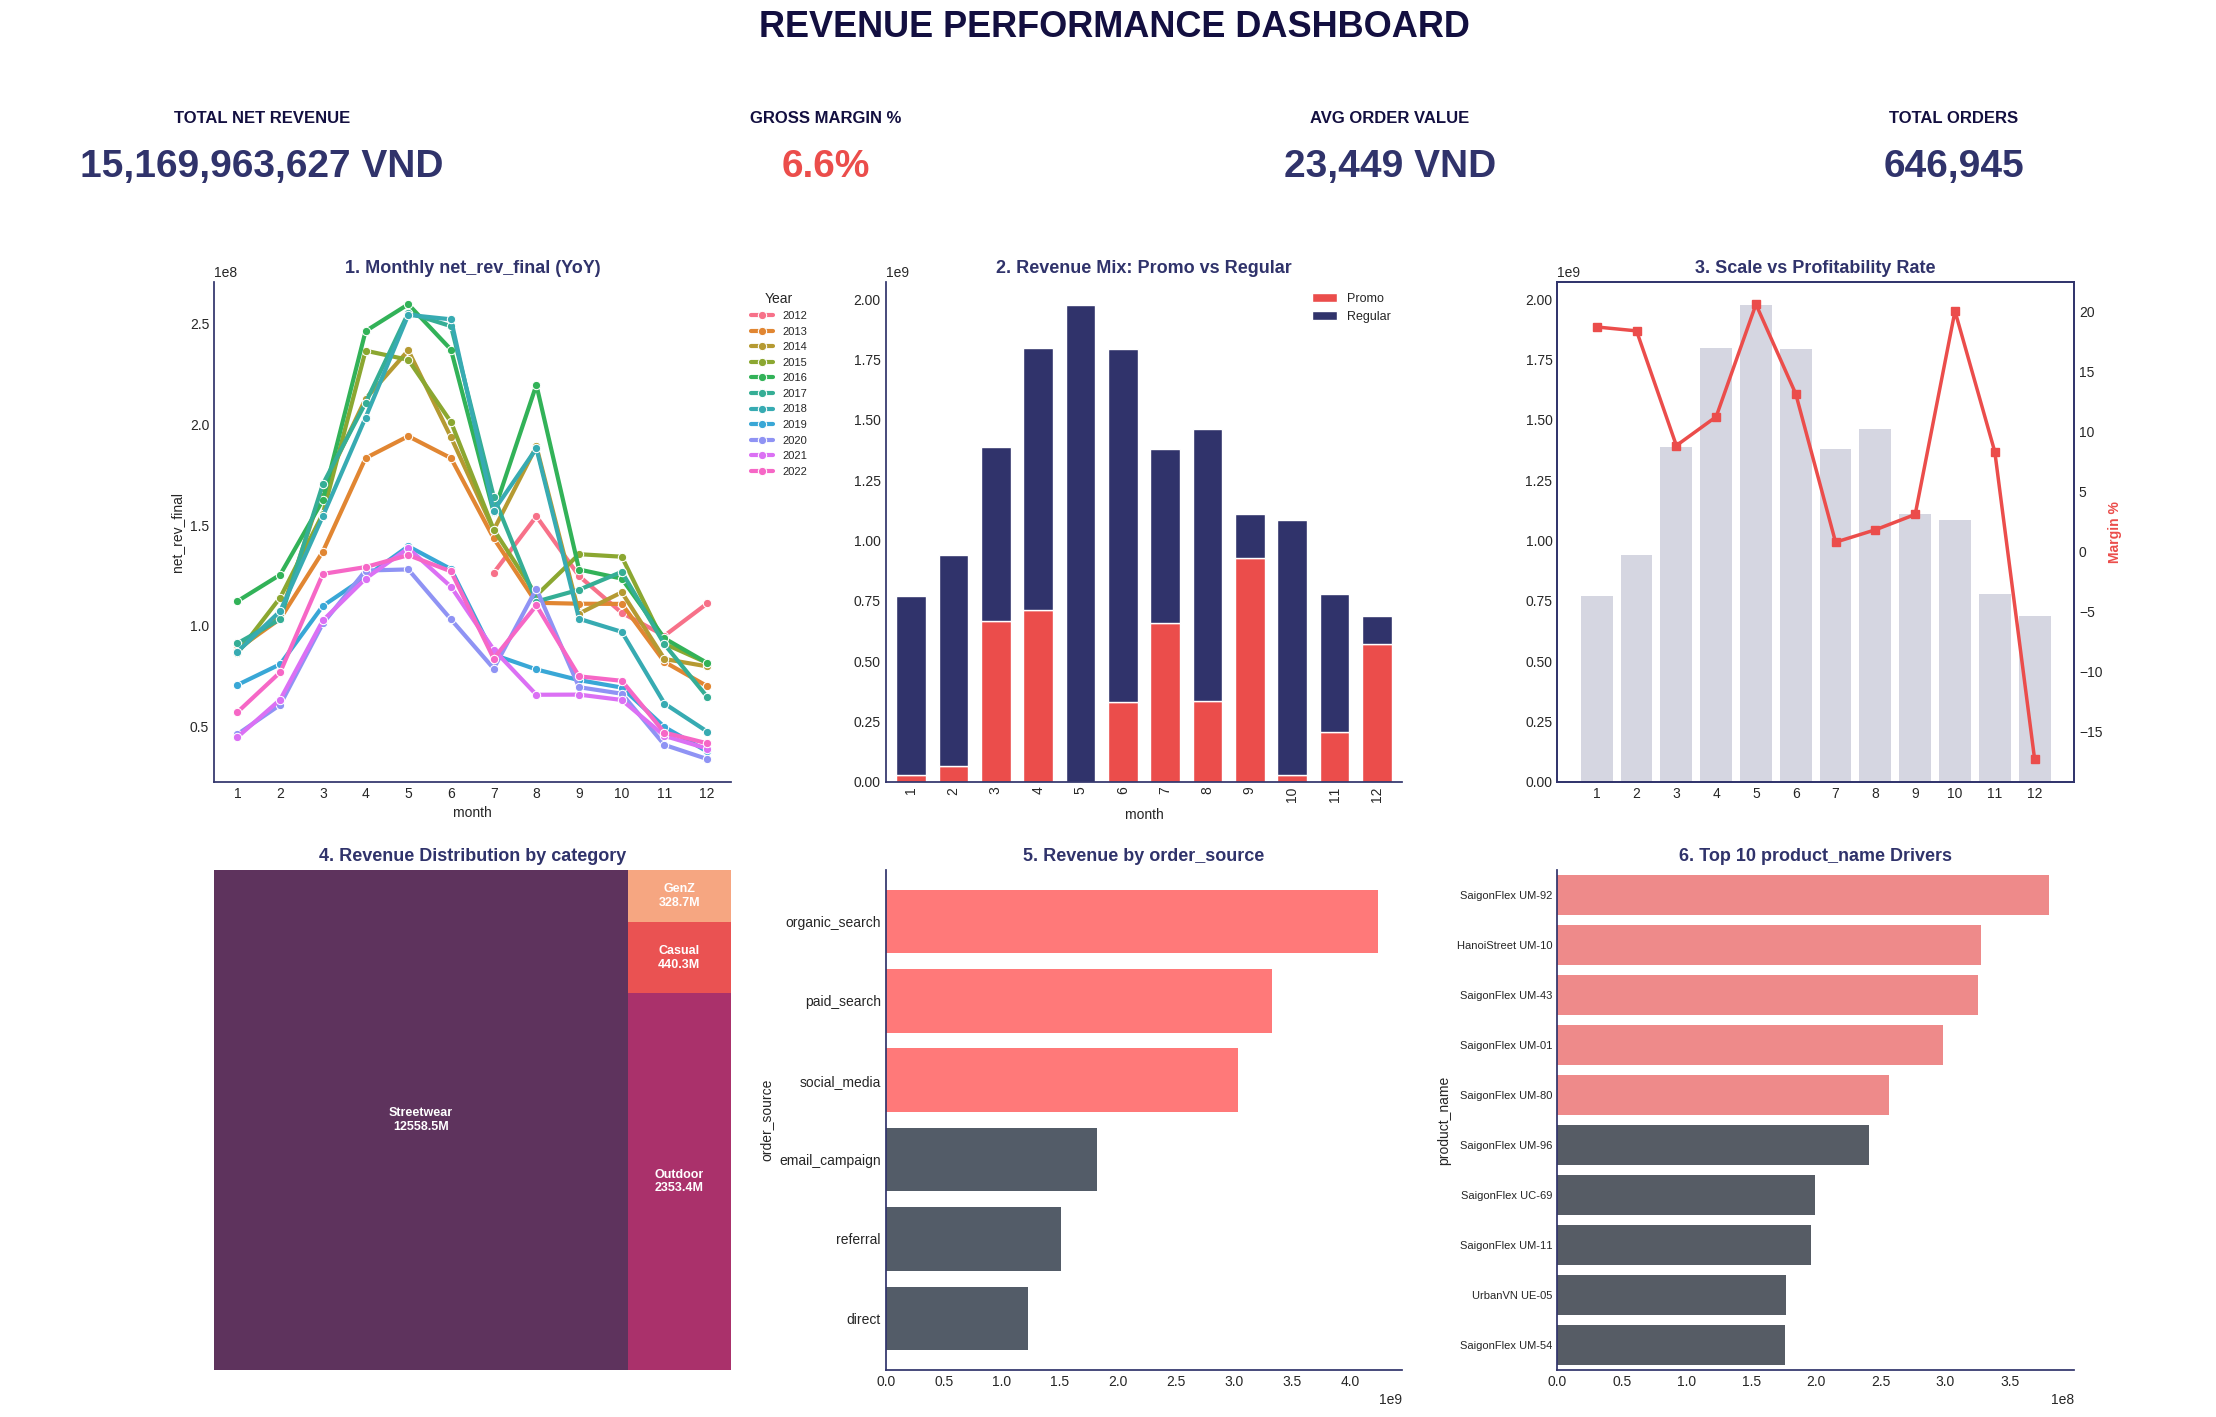

In [5]:
# ============================================================================
# ⭐ ALL-IN-ONE VIVID DASHBOARD - COMPACT LAYOUT
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify 
import warnings

warnings.filterwarnings('ignore')

# --- CẤU HÌNH MÀU SẮC ---
C_INDIGO  = '#30336B'
C_CRIMSON = '#EB4D4B'
C_TEXT    = '#130F40'
C_LIGHT_INDIGO = '#535C68' 
C_SOFT_RED     = '#FF7979' 

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'axes.facecolor': '#FFFFFF',
    'axes.edgecolor': C_INDIGO,
    'grid.alpha': 0.1,
    'font.family': 'sans-serif'
})

def run_vivid_dashboard_v3(products, orders, order_items, returns):
    # --- 1. XỬ LÝ DỮ LIỆU ---
    oi_merged = order_items.merge(products[['product_id', 'product_name', 'category', 'cogs']], on='product_id', how='left')
    oi_merged['revenue_type'] = np.where(oi_merged['promo_id'].isna(), 'Regular', 'Promo')
    oi_merged['net_rev'] = (oi_merged['quantity'] * oi_merged['unit_price']) - oi_merged['discount_amount']
    oi_merged['profit'] = oi_merged['net_rev'] - (oi_merged['quantity'] * oi_merged['cogs'])

    order_level = oi_merged.groupby(['order_id', 'revenue_type']).agg({'net_rev': 'sum', 'profit': 'sum'}).reset_index()
    order_level = order_level.merge(orders[['order_id', 'order_date', 'order_source']], on='order_id', how='left')
    
    refunds = returns.groupby('order_id')['refund_amount'].sum().reset_index()
    order_level = order_level.merge(refunds, on='order_id', how='left').fillna(0)
    order_level['net_rev_final'] = order_level['net_rev'] - order_level['refund_amount']
    order_level['month'] = order_level['order_date'].dt.month
    order_level['year'] = order_level['order_date'].dt.year

    # --- 2. TÍNH TOÁN KPI ---
    total_net = order_level['net_rev_final'].sum()
    total_prof = order_level['profit'].sum() - order_level['refund_amount'].sum()
    margin_pct = (total_prof / total_net * 100) if total_net != 0 else 0
    aov_val = total_net / order_level['order_id'].nunique() if order_level['order_id'].nunique() != 0 else 0
    total_ord = order_level['order_id'].nunique()

    # --- 3. KHỞI TẠO FIGURE ---
    fig = plt.figure(figsize=(24, 16)) # Giảm nhẹ chiều cao tổng thể để dashboard trông đặc hơn
    # hspace giảm xuống 0.2 để thu hẹp khoảng cách các hàng biểu đồ
    gs = fig.add_gridspec(3, 3, height_ratios=[0.05, 0.45, 0.45], hspace=0.25, wspace=0.3)

    # ===== TẦNG 0: 4 KPI CARDS (Dịch xuống gần biểu đồ hơn) =====
    kpis = [
        ("TOTAL NET REVENUE", f"{total_net:,.0f} VND", C_INDIGO),
        ("GROSS MARGIN %", f"{margin_pct:.1f}%", C_CRIMSON),
        ("AVG ORDER VALUE", f"{aov_val:,.0f} VND", C_INDIGO),
        ("TOTAL ORDERS", f"{total_ord:,.0f}", C_INDIGO)
    ]

    for i in range(4):
        # Tọa độ y được chỉnh về 0.85 (thay vì 0.88) để sát tầng 1
        ax_card = fig.add_axes([0.04 + i*0.235, 0.85, 0.21, 0.06])
        ax_card.set_facecolor('none')
        for spine in ax_card.spines.values():
            spine.set_visible(False)
        ax_card.text(0.5, 0.7, kpis[i][0], ha='center', va='center', fontsize=12, fontweight='bold', color=C_TEXT)
        ax_card.text(0.5, 0.2, kpis[i][1], ha='center', va='center', fontsize=28, fontweight='bold', color=kpis[i][2])
        ax_card.set_xticks([]); ax_card.set_yticks([])

    # ===== TẦNG 1 & 2: CÁC BIỂU ĐỒ =====

    # 1. Line Chart: YoY (Chỉ trục X,Y)
    ax1 = fig.add_subplot(gs[1, 0])
    yoy_data = order_level.groupby(['year', 'month'])['net_rev_final'].sum().reset_index()
    sns.lineplot(data=yoy_data, x='month', y='net_rev_final', hue='year', 
                 palette=sns.color_palette("husl", yoy_data['year'].nunique()), 
                 linewidth=3, marker='o', markersize=6, ax=ax1)
    ax1.set_title('1. Monthly net_rev_final (YoY)', fontweight='bold', color=C_INDIGO, fontsize=13)
    ax1.set_xticks(range(1, 13))
    ax1.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
    ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

    # 2. Stacked Bar: Promo vs Regular (Chỉ trục X,Y)
    ax2 = fig.add_subplot(gs[1, 1])
    promo_stack = order_level.groupby(['month', 'revenue_type'])['net_rev_final'].sum().unstack().fillna(0)
    promo_stack.plot(kind='bar', stacked=True, ax=ax2, color=[C_CRIMSON, C_INDIGO], edgecolor='white', width=0.7)
    ax2.set_title('2. Revenue Mix: Promo vs Regular', fontweight='bold', color=C_INDIGO, fontsize=13)
    ax2.legend(frameon=False, fontsize=9)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

    # 3. Combo Chart: Bar & Margin
    ax3 = fig.add_subplot(gs[1, 2])
    combo = order_level.groupby('month').agg({'net_rev_final':'sum', 'profit':'sum'}).reset_index()
    ax3.bar(combo['month'], combo['net_rev_final'], color=C_INDIGO, alpha=0.2)
    ax3_twin = ax3.twinx()
    ax3_twin.plot(combo['month'], (combo['profit']/combo['net_rev_final']*100), color=C_CRIMSON, marker='s', linewidth=2.5)
    ax3_twin.set_ylabel('Margin %', color=C_CRIMSON, fontweight='bold', fontsize=10)
    ax3.set_title('3. Scale vs Profitability Rate', fontweight='bold', color=C_INDIGO, fontsize=13)
    ax3.set_xticks(range(1, 13))


    # 4. Treemap: category
    ax4 = fig.add_subplot(gs[2, 0])
    cat_dist = oi_merged.groupby('category')['net_rev'].sum().sort_values(ascending=False).reset_index()
    tm_labels = [f"{c}\n{v/1e6:.1f}M" for c, v in zip(cat_dist['category'], cat_dist['net_rev'])]
    squarify.plot(sizes=cat_dist['net_rev'], label=tm_labels, color=sns.color_palette("rocket", len(cat_dist)), 
                  alpha=0.9, ax=ax4, text_kwargs={'color':'white', 'weight':'bold', 'fontsize':9})
    ax4.set_title('4. Revenue Distribution by category', fontweight='bold', color=C_INDIGO, fontsize=13)
    ax4.axis('off')

    # 5. Horizontal Bar: order_source (Sắc độ nhẹ, Chỉ trục X,Y)
    ax5 = fig.add_subplot(gs[2, 1])
    src_data = order_level.groupby('order_source')['net_rev_final'].sum().sort_values()
    colors_5 = [C_LIGHT_INDIGO] * (len(src_data) // 2) + [C_SOFT_RED] * (len(src_data) - len(src_data) // 2)
    src_data.plot(kind='barh', color=colors_5, ax=ax5, width=0.8)
    ax5.set_title('5. Revenue by order_source', fontweight='bold', color=C_INDIGO, fontsize=13)
    ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

    # 6. Bar Chart: product_name (Sắc độ nhẹ, Chỉ trục X,Y)
    ax6 = fig.add_subplot(gs[2, 2])
    top10 = oi_merged.groupby('product_name')['net_rev'].sum().sort_values(ascending=False).head(10)
    colors_6 = [C_SOFT_RED] * 5 + [C_LIGHT_INDIGO] * 5
    sns.barplot(x=top10.values, y=top10.index, palette=colors_6, ax=ax6)
    ax6.set_title('6. Top 10 product_name Drivers', fontweight='bold', color=C_INDIGO, fontsize=13)
    ax6.tick_params(axis='y', labelsize=8)
    ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

    plt.suptitle('REVENUE PERFORMANCE DASHBOARD', fontsize=26, fontweight='bold', color=C_TEXT, y=0.96)
    plt.tight_layout(rect=[0, 0, 0.95, 0.93])
    plt.show()

# Chạy Dashboard
if 'order_items' in locals():
    run_vivid_dashboard_v3(products, orders, order_items, returns)

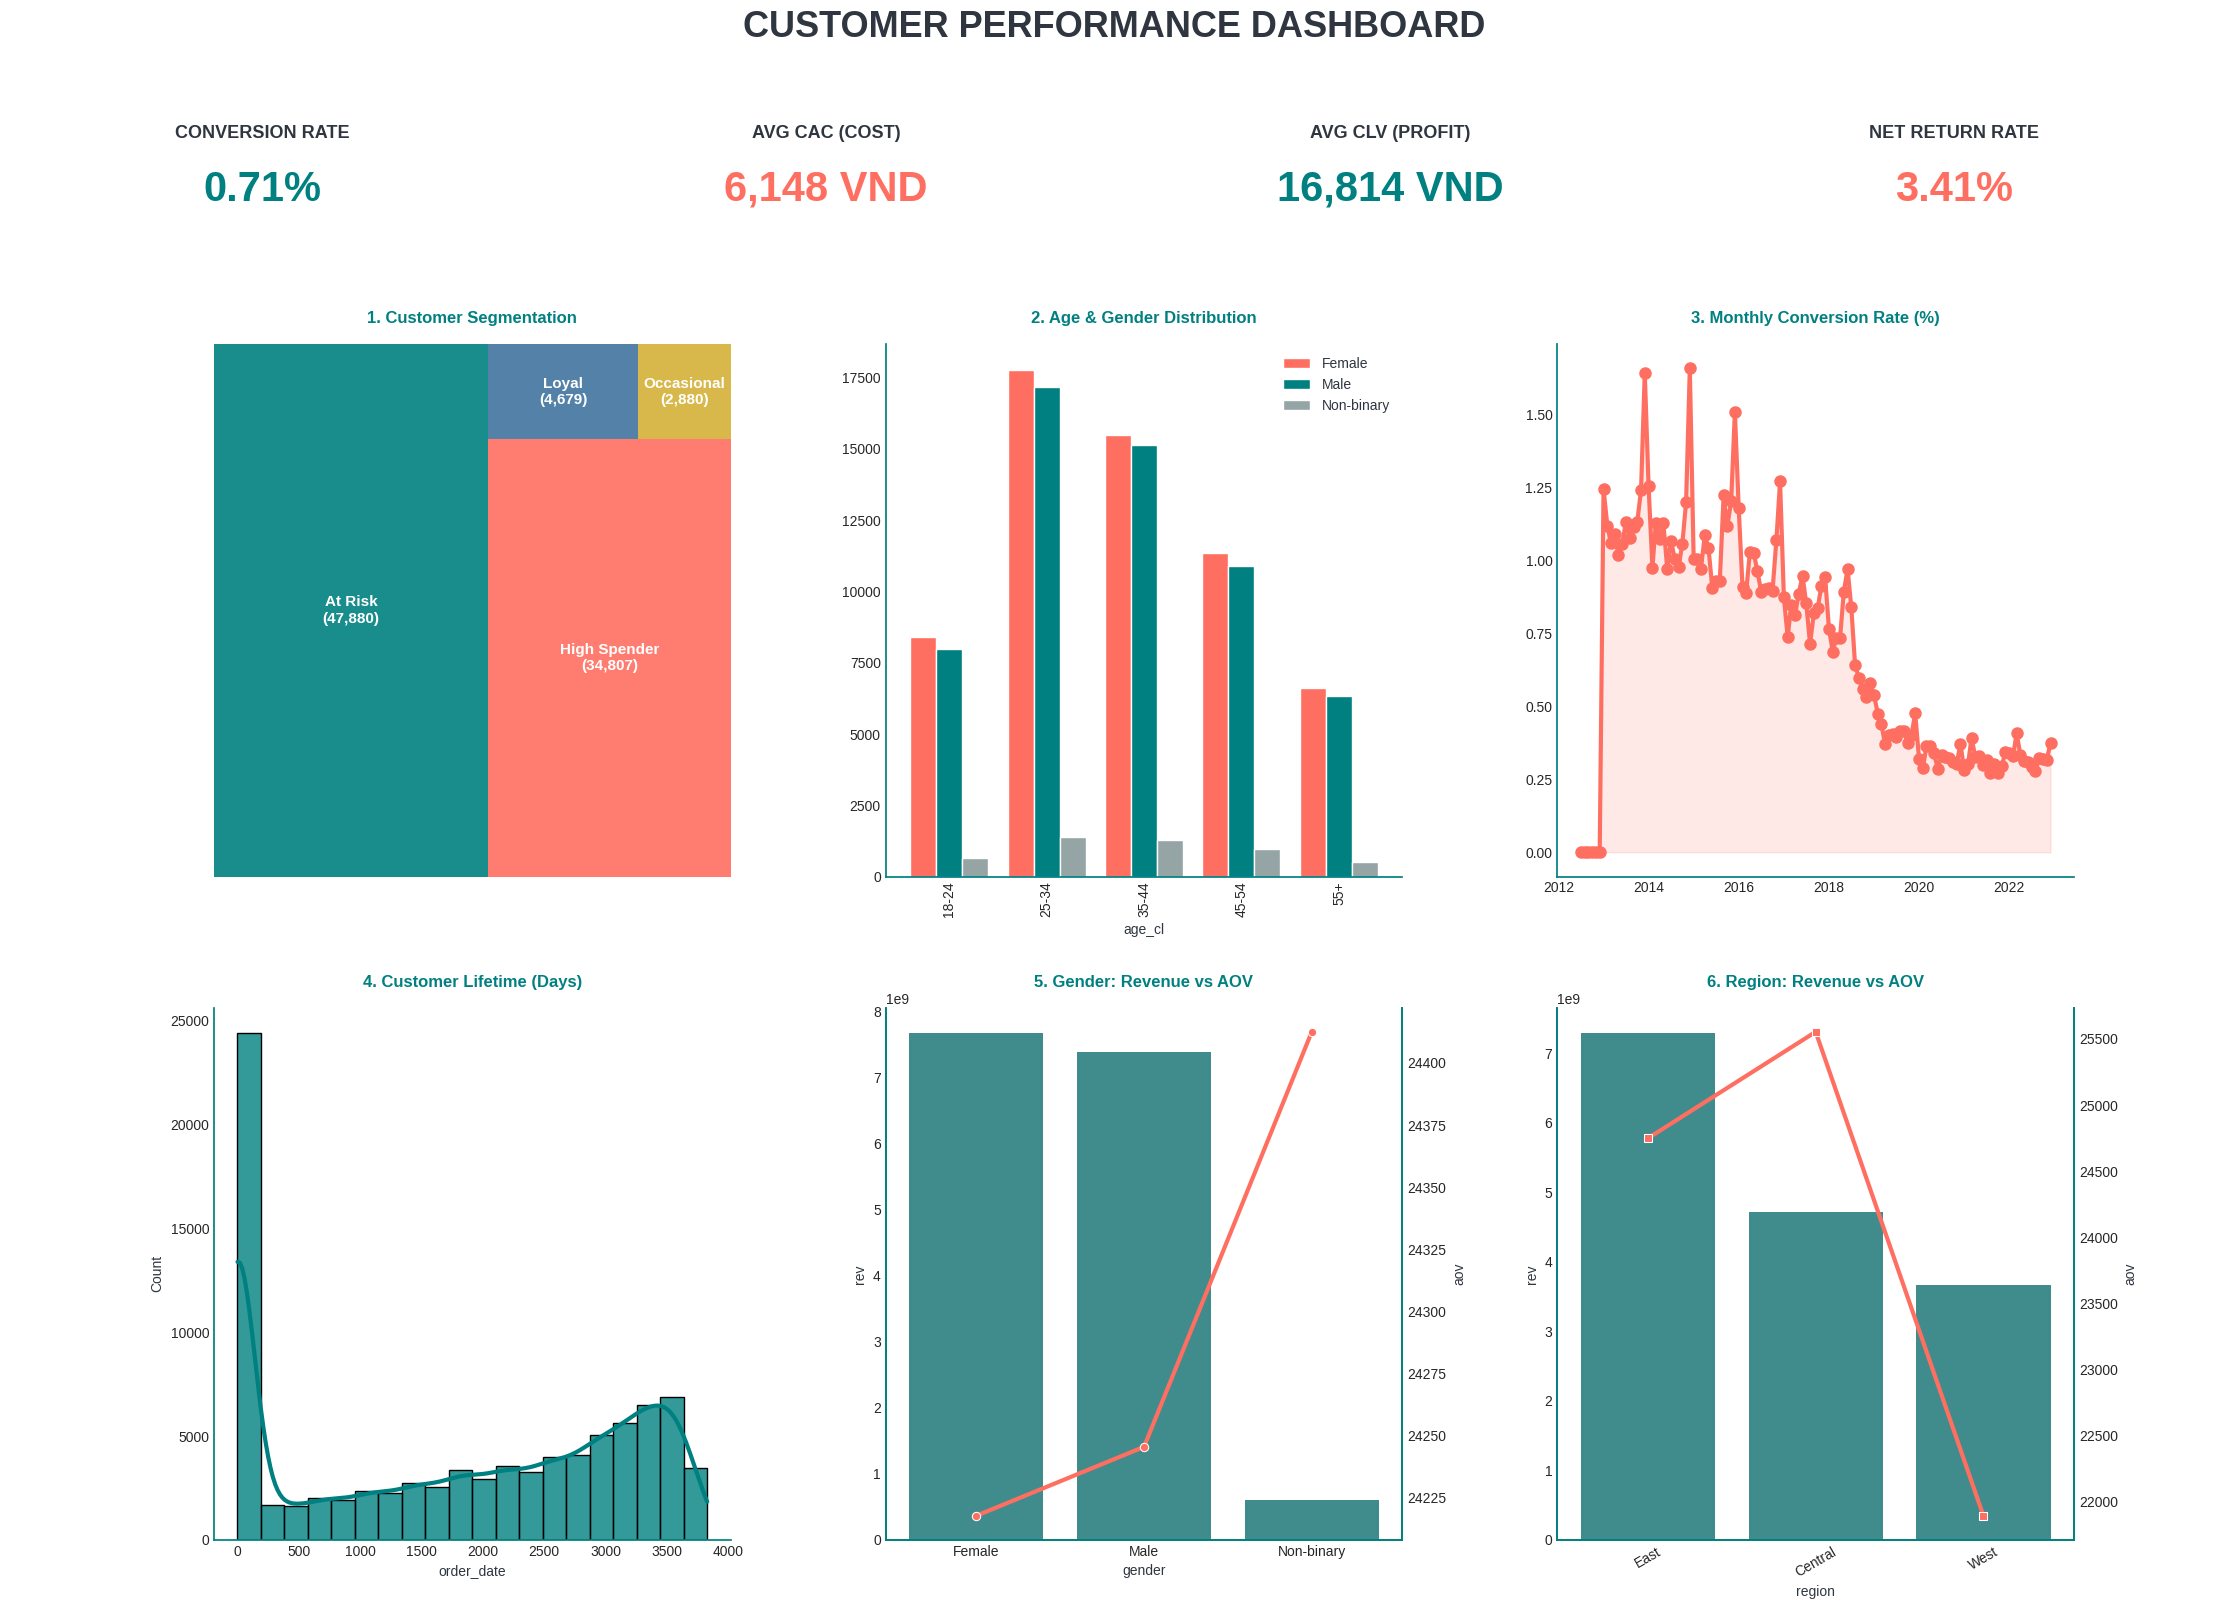

In [6]:
# ============================================================================
# ⭐ CUSTOMER INSIGHTS DASHBOARD V6 (SPACING ADJUSTED)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify 
from datetime import timedelta
import warnings

warnings.filterwarnings('ignore')

# --- CẤU HÌNH MÀU SẮC ĐẬM ---
C_BOLD_TEAL  = '#008080'  # Xanh Teal đậm
C_BOLD_CORAL = '#FF6F61'  # Cam Coral đậm
C_BOLD_GOLD  = '#D4AF37'  # Vàng Gold đậm
C_TEXT       = '#2F3640'  # Xám than đậm
C_BG         = '#FFFFFF'  # Nền trắng

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'axes.facecolor': C_BG, 
    'axes.edgecolor': C_BOLD_TEAL, 
    'font.family': 'sans-serif',
    'text.color': C_TEXT,
    'axes.labelcolor': C_TEXT
})

def run_customer_vivid_dashboard_v6(customers, orders, order_items, returns, web_traffic, products, geo):
    # --- 1. CHUẨN BỊ DỮ LIỆU ---
    order_items['revenue'] = (order_items['quantity'] * order_items['unit_price']) - order_items['discount_amount'].fillna(0)
    
    df_full = order_items.merge(orders[['order_id', 'customer_id', 'zip']], on='order_id', how='left')
    df_full = df_full.merge(customers[['customer_id', 'gender', 'age_group']], on='customer_id', how='left')
    df_full = df_full.merge(geo[['zip', 'region']], on='zip', how='left')

    # --- 2. TÍNH TOÁN KPI ---
    total_orders = orders['order_id'].nunique()
    total_sessions = web_traffic['sessions'].sum()
    cr_value = (total_orders / total_sessions) * 100
    total_promo_cost = order_items['discount_amount'].sum()
    cac_value = total_promo_cost / customers['customer_id'].nunique()
    
    df_profit = order_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')
    df_profit['profit'] = df_profit['revenue'] - (df_profit['quantity'] * df_profit['cogs'])
    clv_per_customer = df_profit.merge(orders[['order_id', 'customer_id']], on='order_id').groupby('customer_id')['profit'].sum()
    return_rate = (returns['return_quantity'].sum() / order_items['quantity'].sum()) * 100

    # --- 3. KHỞI TẠO LAYOUT ---
    fig = plt.figure(figsize=(24, 18)) # Giảm nhẹ chiều cao tổng để layout cân đối hơn
    # hspace được điều chỉnh để tạo khoảng cách giữa các hàng biểu đồ
    gs = fig.add_gridspec(3, 3, height_ratios=[0.05, 0.45, 0.45], hspace=0.35, wspace=0.3)

    # ===== TẦNG 0: KPI CARDS (Hạ thấp xuống so với tiêu đề) =====
    kpis = [("CONVERSION RATE", f"{cr_value:.2f}%", C_BOLD_TEAL),
            ("AVG CAC (COST)", f"{cac_value:,.0f} VND", C_BOLD_CORAL),
            ("AVG CLV (PROFIT)", f"{clv_per_customer.mean():,.0f} VND", C_BOLD_TEAL),
            ("NET RETURN RATE", f"{return_rate:.2f}%", C_BOLD_CORAL)]

    # Điều chỉnh y=0.84 để tạo khoảng cách với tiêu đề (y=0.96)
    for i, (title, val, color) in enumerate(kpis):
        ax = fig.add_axes([0.04 + i*0.235, 0.84, 0.21, 0.07], facecolor='none')
        for s in ax.spines.values(): s.set_visible(False)
        ax.text(0.5, 0.7, title, ha='center', fontsize=13, fontweight='bold', color=C_TEXT)
        ax.text(0.5, 0.2, val, ha='center', fontsize=30, fontweight='bold', color=color)
        ax.set_xticks([]); ax.set_yticks([])

    # ===== TẦNG 1: CUSTOMER INSIGHTS =====
    # 1. Treemap Segmentation
    ax1 = fig.add_subplot(gs[1, 0])
    snapshot = orders["order_date"].max() + timedelta(days=1)
    rfm = orders.groupby('customer_id').agg({'order_date': lambda x: (snapshot - x.max()).days, 'order_id': 'nunique'}).rename(columns={'order_date': 'R', 'order_id': 'F'})
    rfm['M'] = clv_per_customer
    rfm['Segment'] = np.select(
        [(rfm['R'] <= 90) & (rfm['F'] > rfm['F'].median()), (rfm['M'] > rfm['M'].median()*1.5), (rfm['R'] > 180)],
        ['Loyal', 'High Spender', 'At Risk'], default='Occasional'
    )
    seg_data = rfm['Segment'].value_counts()
    bold_palette = [C_BOLD_TEAL, C_BOLD_CORAL, '#40739E', C_BOLD_GOLD]
    squarify.plot(sizes=seg_data, label=[f"{n}\n({v:,})" for n, v in seg_data.items()], color=bold_palette, alpha=0.9, ax=ax1, text_kwargs={'color':'white', 'weight':'bold', 'fontsize':11})
    ax1.set_title('1. Customer Segmentation', fontweight='bold', color=C_BOLD_TEAL, pad=15)
    ax1.axis('off')

    # 2. Age Distribution
    ax2 = fig.add_subplot(gs[1, 1])
    age_map = {"Under 18": "<18", "18–24": "18-24", "25–34": "25-34", "35–44": "35-44", "45+": "45-54"}
    customers['age_cl'] = customers['age_group'].replace(age_map)
    customers.groupby(['age_cl', 'gender']).size().unstack().plot(kind='bar', ax=ax2, color=[C_BOLD_CORAL, C_BOLD_TEAL, '#95A5A6'], width=0.8, edgecolor='white')
    ax2.set_title('2. Age & Gender Distribution', fontweight='bold', color=C_BOLD_TEAL, pad=15)
    ax2.legend(frameon=False)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

    # 3. Monthly CR Trend
    ax3 = fig.add_subplot(gs[1, 2])
    m_cr = (orders.set_index('order_date').resample('MS')['order_id'].nunique() / web_traffic.set_index('date').resample('MS')['sessions'].sum() * 100).fillna(0)
    ax3.plot(m_cr.index, m_cr.values, marker='o', color=C_BOLD_CORAL, lw=3, markersize=8)
    ax3.fill_between(m_cr.index, m_cr.values, color=C_BOLD_CORAL, alpha=0.15)
    ax3.set_title('3. Monthly Conversion Rate (%)', fontweight='bold', color=C_BOLD_TEAL, pad=15)
    ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

    # ===== TẦNG 2: PERFORMANCE ANALYSIS =====
    # 4. Customer Lifetime
    ax4 = fig.add_subplot(gs[2, 0])
    clt = (orders.groupby('customer_id')['order_date'].max() - orders.groupby('customer_id')['order_date'].min()).dt.days
    sns.histplot(clt, bins=20, color=C_BOLD_TEAL, kde=True, ax=ax4, alpha=0.8, 
                 line_kws={'color': C_BOLD_CORAL, 'linewidth': 3})
    ax4.set_title('4. Customer Lifetime (Days)', fontweight='bold', color=C_BOLD_TEAL, pad=15)
    ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

    # 5. Gender Performance
    ax5 = fig.add_subplot(gs[2, 1])
    g_stats = df_full.groupby('gender').agg(rev=('revenue', 'sum'), cnt=('order_id', 'nunique'))
    g_stats['aov'] = g_stats['rev'] / g_stats['cnt']
    sns.barplot(x=g_stats.index, y=g_stats['rev'], color=C_BOLD_TEAL, alpha=0.8, ax=ax5)
    ax5.spines['top'].set_visible(False)
    ax5_t = ax5.twinx()
    sns.lineplot(x=g_stats.index, y=g_stats['aov'], color=C_BOLD_CORAL, marker='o', lw=3, ax=ax5_t)
    ax5_t.spines['top'].set_visible(False)
    ax5.set_title('5. Gender: Revenue vs AOV', fontweight='bold', color=C_BOLD_TEAL, pad=15)

    # 6. Regional Performance
    ax6 = fig.add_subplot(gs[2, 2])
    r_stats = df_full.groupby('region').agg(rev=('revenue', 'sum'), cnt=('order_id', 'nunique')).sort_values('rev', ascending=False)
    r_stats['aov'] = r_stats['rev'] / r_stats['cnt']
    sns.barplot(x=r_stats.index, y=r_stats['rev'], color=C_BOLD_TEAL, alpha=0.8, ax=ax6)
    ax6.spines['top'].set_visible(False)
    plt.setp(ax6.get_xticklabels(), rotation=30)
    ax6_t = ax6.twinx()
    sns.lineplot(x=r_stats.index, y=r_stats['aov'], color=C_BOLD_CORAL, marker='s', lw=3, ax=ax6_t)
    ax6_t.spines['top'].set_visible(False)
    ax6.set_title('6. Region: Revenue vs AOV', fontweight='bold', color=C_BOLD_TEAL, pad=15)

    # --- ĐIỀU CHỈNH KHOẢNG CÁCH TỔNG THỂ ---
    # y=0.96 là vị trí tiêu đề
    plt.suptitle('CUSTOMER PERFORMANCE DASHBOARD', fontsize=26, fontweight='bold', color=C_TEXT, y=0.96)
    
    # rect=[0, 0, 1, 0.82] để các biểu đồ bắt đầu từ dưới y=0.82, nhường chỗ cho Tầng 0
    plt.tight_layout(rect=[0, 0, 1, 0.82])
    plt.show()

# Gọi hàm
run_customer_vivid_dashboard_v6(customers, orders, order_items, returns, web_traffic, products, geo)